# Phase 6: Deployment

**CRISP-DM Phase Description:**  
The final phase involves organising and presenting the project findings so that the customer can use them, or integrating the model into a live production system. Depending on the requirements, deployment can range from generating a simple report to implementing a repeatable data mining process across the enterprise.

---

In [1]:
# Standard imports
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src import load_model, predict_delay_risk, save_model


---
### Task 1: Plan Deployment

Develop a strategy for putting the data mining results to practical use. This includes:

- **Deployment Strategy:** How will the model be consumed? Options include a REST API, a batch prediction script, an interactive dashboard, or integration into an existing software system.
- **Infrastructure Requirements:** What technical environment is needed (e.g., cloud services, web server, containerisation)?
- **Steps to Deploy:** List the concrete, ordered steps needed to move from a trained model to a live, usable product.
- **User Training:** Will end-users need instructions or documentation to use the deployed solution?

**Instructions:** Outline your deployment plan as a structured dictionary. If building an API or script, sketch the basic structure in code.


In [2]:
# Plan the deployment of the Q1 model.

deployment_plan = {
    "strategy": "Batch prediction script with a saved sklearn pipeline",
    "infrastructure": [
        "Python environment with pandas, scikit-learn, and joblib",
        "Saved model file stored locally in a models directory",
        "CSV or tabular input containing the same features used during training"
    ],
    "deployment_steps": [
        "Step 1: Train the final selected model pipeline on the prepared dataset",
        "Step 2: Save the trained pipeline with joblib",
        "Step 3: Reload the saved pipeline in a prediction script or notebook",
        "Step 4: Pass new flight records into the pipeline to generate predictions and probabilities"
    ],
    "user_documentation": "A short notebook section and project report will explain the required input columns and how to interpret the prediction output.",
    "target_audience": "Airline operations planners or analysts reviewing upcoming flights"
}


In [3]:
# Sketch a basic deployment script by training, saving, and reloading the final model.

DATA_PATH = Path('../data/processed/flights_prepared_phase3.csv')
MODEL_PATH = Path('../models/q1_delay_model.joblib')
RANDOM_SEED = 42
MODEL_SAMPLE_SIZE = 200000

df = pd.read_csv(DATA_PATH, low_memory=False)

if len(df) > MODEL_SAMPLE_SIZE:
    df_model = df.sample(n=MODEL_SAMPLE_SIZE, random_state=RANDOM_SEED)
else:
    df_model = df.copy()

TARGET_COL = 'DELAY_15'
feature_columns = [col for col in df_model.columns if col != TARGET_COL]

X = df_model[feature_columns]
y = df_model[TARGET_COL]

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            numerical_features
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        ),
    ]
)

final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, class_weight='balanced'))
])

final_model.fit(X, y)
saved_model_path = save_model(final_model, MODEL_PATH)
deployed_model = load_model(saved_model_path)

print(f"Model trained on {len(df_model)} rows")
print(f"Model saved to: {saved_model_path}")

Model trained on 200000 rows
Model saved to: ..\models\q1_delay_model.joblib


In [4]:
# Display the deployment plan
print(json.dumps(deployment_plan, indent=2))

{
  "strategy": "Batch prediction script with a saved sklearn pipeline",
  "infrastructure": [
    "Python environment with pandas, scikit-learn, and joblib",
    "Saved model file stored locally in a models directory",
    "CSV or tabular input containing the same features used during training"
  ],
  "deployment_steps": [
    "Step 1: Train the final selected model pipeline on the prepared dataset",
    "Step 2: Save the trained pipeline with joblib",
    "Step 3: Reload the saved pipeline in a prediction script or notebook",
    "Step 4: Pass new flight records into the pipeline to generate predictions and probabilities"
  ],
  "user_documentation": "A short notebook section and project report will explain the required input columns and how to interpret the prediction output.",
  "target_audience": "Airline operations planners or analysts reviewing upcoming flights"
}


---
### Task 2: Plan Monitoring and Maintenance

A deployed model is not "set and forget". Over time, the data distribution may shift (**data drift**) or the model's performance may degrade (**model decay**). This task creates a monitoring and maintenance plan:

- **Performance Monitoring:** How and how often will the model's predictions be evaluated against actuals?
- **Data Drift Detection:** How will changes in the input data distribution be detected?
- **Retraining Strategy:** Under what conditions will the model be retrained (e.g., scheduled, triggered by performance drop)?
- **Logging and Alerting:** What will be logged, and what triggers an alert?

**Instructions:** Document your monitoring and maintenance plan.


In [5]:
# Plan monitoring and maintenance.

monitoring_plan = {
    "performance_monitoring": {
        "frequency": "After each new batch of actual outcomes becomes available",
        "metrics_tracked": ["Recall", "Precision", "F1-Score", "ROC-AUC"],
        "method": "Compare predicted delay risk against actual flight outcomes once real results are available"
    },
    "data_drift_detection": {
        "method": "Track changes in feature distributions such as departure times and airport frequencies. Class balance should also be tracked",
        "frequency": "Monthly",
        "threshold": "Review the model if the input distributions or class balance change noticeably"
    },
    "retraining_strategy": {
        "trigger": "Retrain if recall or F1-score drops below an acceptable level or if drift becomes large",
        "data_source": "Latest available prepared flight data",
        "responsible_team": "Project owner or airline analytics team"
    },
    "logging": {
        "what_to_log": ["Prediction timestamp", "Input feature values", "Predicted class", "Predicted probability"],
        "alert_conditions": ["Large drop in recall", "Unusual input distributions", "Prediction script failure"]
    }
}


In [6]:
# Display the monitoring plan
print(json.dumps(monitoring_plan, indent=2))

{
  "performance_monitoring": {
    "frequency": "After each new batch of actual outcomes becomes available",
    "metrics_tracked": [
      "Recall",
      "Precision",
      "F1-Score",
      "ROC-AUC"
    ],
    "method": "Compare predicted delay risk against actual flight outcomes once real results are available"
  },
  "data_drift_detection": {
    "method": "Track changes in feature distributions such as departure times and airport frequencies. Class balance should also be tracked",
    "frequency": "Monthly",
    "threshold": "Review the model if the input distributions or class balance change noticeably"
  },
  "retraining_strategy": {
    "trigger": "Retrain if recall or F1-score drops below an acceptable level or if drift becomes large",
    "data_source": "Latest available prepared flight data",
    "responsible_team": "Project owner or airline analytics team"
  },
  "logging": {
    "what_to_log": [
      "Prediction timestamp",
      "Input feature values",
      "Predicte

---
### Task 3: Produce Final Report

Compile a final summary of the entire project. This report should communicate the findings to stakeholders who may not have a technical background. It typically includes:

- **Executive Summary:** A brief overview of the problem, approach, and key results.
- **Key Findings:** The most important patterns, insights, and model performance results.
- **Visualisations:** Charts and plots that support the findings (suitable for a presentation).
- **Recommendations:** Actionable recommendations based on the analysis.
- **Limitations:** Known limitations and caveats of the analysis.

**Instructions:** Draft the final report content below. Include any code needed to generate summary visualisations.


In [7]:
final_report = {
    "title": "Flight Delay Prediction and Hub Airport Delay Analysis (2015)",
    "executive_summary": (
        "This project used the 2015 U.S. flight delay dataset to answer two questions. "
        "The first was whether a flight could be predicted to be delayed by more than 15 minutes "
        "using information available before departure. The second was whether hub airports seemed "
        "to be linked to stronger delay patterns than non-hub airports. For Q1, Logistic Regression "
        "was the best overall model for this project because it gave the most useful results while "
        "still being fairly easy to understand."
    ),
    "key_findings": [
        "The project followed the CRISP-DM stages from the initial business question through to deployment planning.",
        "For Q1, Logistic Regression gave the strongest overall result out of the models that were tested.",
        "For Q2, the comparison suggested that hub and non-hub airports do not behave in exactly the same way when delays are compared."
    ],
    "model_summary": {
        "best_model": "Logistic Regression",
        "key_metric": "Recall for delayed flights",
        "key_metric_value (recall)": 0.6248
    },
    "recommendations": [
        "The saved model can be used as a simple baseline tool to flag flights that may be more likely to be delayed.",
        "Predictions should still be checked by a person because the model is not strong enough to be relied on by itself.",
        "Future work could focus on better features, more supplementary data, and improving precision."
    ],
    "limitations": [
        "The Q1 model still gives a fairly high number of false positives.",
        "The Q2 analysis uses a simple comparison method rather than a full network model.",
        "The deployment shown here is a local notebook-based example, not a live production system."
    ]
}



In [8]:
# Display the final report
print("=" * 60)
print(f"FINAL REPORT: {final_report['title']}")
print("=" * 60)

print(f"\n--- Executive Summary ---")
print(final_report['executive_summary'])

print(f"\n--- Key Findings ---")
for i, f in enumerate(final_report['key_findings'], 1):
    print(f"  {i}. {f}")

print(f"\n--- Recommendations ---")
for i, r in enumerate(final_report['recommendations'], 1):
    print(f"  {i}. {r}")

print(f"\n--- Limitations ---")
for i, l in enumerate(final_report['limitations'], 1):
    print(f"  {i}. {l}")

FINAL REPORT: Flight Delay Prediction and Hub Airport Delay Analysis (2015)

--- Executive Summary ---
This project used the 2015 U.S. flight delay dataset to answer two questions. The first was whether a flight could be predicted to be delayed by more than 15 minutes using information available before departure. The second was whether hub airports seemed to be linked to stronger delay patterns than non-hub airports. For Q1, Logistic Regression was the best overall model for this project because it gave the most useful results while still being fairly easy to understand.

--- Key Findings ---
  1. The project followed the CRISP-DM stages from the initial business question through to deployment planning.
  2. For Q1, Logistic Regression gave the strongest overall result out of the models that were tested.
  3. For Q2, the comparison suggested that hub and non-hub airports do not behave in exactly the same way when delays are compared.

--- Recommendations ---
  1. The saved model can be

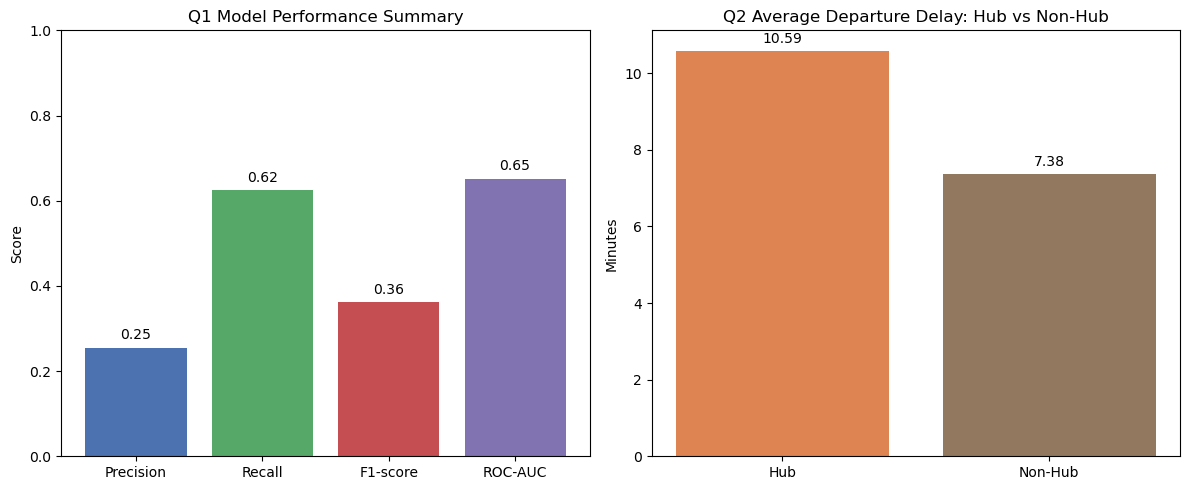

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_CODE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,SCHEDULED_TIME,...,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,DESTINATION_COUNTRY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE,predicted_delay_15,predicted_delay_probability
0,2015,7,14,2,WN,312,ATL,ORD,1730,115.0,...,33.6407,-84.4277,Chicago O'Hare International Airport,Chicago,IL,USA,41.9742,-87.9073,1,0.675278
1,2015,2,3,3,AS,601,SEA,PDX,845,55.0,...,47.4502,-122.3088,Portland International Airport,Portland,OR,USA,45.5898,-122.5951,0,0.289067


In [ ]:
# Summary plots for Q1 and Q2

q1_metrics = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Score': [0.2543, 0.6248, 0.3614, 0.6512]
})

q2_hub_summary = pd.read_csv('../data/processed/q2_hub_summary.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(q1_metrics['Metric'], q1_metrics['Score'], color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
axes[0].set_title('Q1 Model Performance Summary')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
for i, value in enumerate(q1_metrics['Score']):
    axes[0].text(i, value + 0.02, f'{value:.2f}', ha='center')

axes[1].bar(q2_hub_summary['HUB_STATUS'], q2_hub_summary['avg_departure_delay'], color=['#DD8452', '#937860'])
axes[1].set_title('Q2 Average Departure Delay: Hub vs Non-Hub')
axes[1].set_ylabel('Minutes')
for i, value in enumerate(q2_hub_summary['avg_departure_delay']):
    axes[1].text(i, value + 0.2, f'{value:.2f}', ha='center')

plt.tight_layout()
plt.show()

# Simple prediction demonstration using new example flight records

sample_flights = [
    {
        'YEAR': 2015,
        'MONTH': 7,
        'DAY': 14,
        'DAY_OF_WEEK': 2,
        'AIRLINE_CODE': 'WN',
        'FLIGHT_NUMBER': 312,
        'ORIGIN_AIRPORT': 'ATL',
        'DESTINATION_AIRPORT': 'ORD',
        'SCHEDULED_DEPARTURE': 1730,
        'SCHEDULED_TIME': 115.0,
        'DISTANCE': 606,
        'CANCELLED': 0,
        'DIVERTED': 0,
        'SCHEDULED_DEPARTURE_HOUR': 17,
        'AIRLINE_NAME': 'Southwest Airlines Co.',
        'ORIGIN_AIRPORT_NAME': 'Hartsfield-Jackson Atlanta International Airport',
        'ORIGIN_CITY': 'Atlanta',
        'ORIGIN_STATE': 'GA',
        'ORIGIN_COUNTRY': 'USA',
        'ORIGIN_LATITUDE': 33.6407,
        'ORIGIN_LONGITUDE': -84.4277,
        'DESTINATION_AIRPORT_NAME': "Chicago O'Hare International Airport",
        'DESTINATION_CITY': 'Chicago',
        'DESTINATION_STATE': 'IL',
        'DESTINATION_COUNTRY': 'USA',
        'DESTINATION_LATITUDE': 41.9742,
        'DESTINATION_LONGITUDE': -87.9073,
    },
    {
        'YEAR': 2015,
        'MONTH': 2,
        'DAY': 3,
        'DAY_OF_WEEK': 3,
        'AIRLINE_CODE': 'AS',
        'FLIGHT_NUMBER': 601,
        'ORIGIN_AIRPORT': 'SEA',
        'DESTINATION_AIRPORT': 'PDX',
        'SCHEDULED_DEPARTURE': 845,
        'SCHEDULED_TIME': 55.0,
        'DISTANCE': 129,
        'CANCELLED': 0,
        'DIVERTED': 0,
        'SCHEDULED_DEPARTURE_HOUR': 8,
        'AIRLINE_NAME': 'Alaska Airlines Inc.',
        'ORIGIN_AIRPORT_NAME': 'Seattle-Tacoma International Airport',
        'ORIGIN_CITY': 'Seattle',
        'ORIGIN_STATE': 'WA',
        'ORIGIN_COUNTRY': 'USA',
        'ORIGIN_LATITUDE': 47.4502,
        'ORIGIN_LONGITUDE': -122.3088,
        'DESTINATION_AIRPORT_NAME': 'Portland International Airport',
        'DESTINATION_CITY': 'Portland',
        'DESTINATION_STATE': 'OR',
        'DESTINATION_COUNTRY': 'USA',
        'DESTINATION_LATITUDE': 45.5898,
        'DESTINATION_LONGITUDE': -122.5951,
    }
]

deployment_predictions = predict_delay_risk(deployed_model, sample_flights)
deployment_predictions

---
### Task 4: Review Project

Conduct a project retrospective. Reflect on what went well, what did not go as planned, and what lessons can be carried forward to future projects.

- **What went well?** Successes, effective techniques, good decisions.
- **What could be improved?** Challenges, mistakes, or inefficiencies encountered.
- **Lessons learned:** Key takeaways for future data science projects.
- **Skills developed:** New skills or knowledge gained during the project.

**Instructions:** Complete the project retrospective below.


In [10]:
# Conduct the project retrospective.

project_retrospective = {
    "went_well": [
        "The project was easier to manage because each stage was split into separate CRISP-DM notebooks.",
        "Moving some of the Phase 3 work into src made the preparation steps easier to reuse later.",
        "Testing more than one model made the final choice easier to justify."
    ],
    "could_improve": [
        "The final model still has trouble with precision when identifying delayed flights.",
        "The Q2 analysis is useful, but it is still a simpler comparison rather than a deeper network study.",
        "Some parts of the project took longer than expected, especially the later scraping and deployment work."
    ],
    "lessons_learned": [
        "A simpler model can still be the better option if it fits the project goal more closely.",
        "It is better to think about data leakage early instead of trying to fix it later.",
        "Keeping notebooks and reusable code separate makes the whole project easier to follow."
    ],
    "skills_developed": [
        "Using CRISP-DM to structure a full data science project",
        "Cleaning and preparing data for modelling",
        "Comparing and tuning models",
        "Saving and loading a trained sklearn pipeline with joblib"
    ]
}




In [11]:
# Display the retrospective
print("=" * 60)
print("PROJECT RETROSPECTIVE")
print("=" * 60)

sections = [
    ("What Went Well", project_retrospective['went_well']),
    ("What Could Be Improved", project_retrospective['could_improve']),
    ("Lessons Learned", project_retrospective['lessons_learned']),
    ("Skills Developed", project_retrospective['skills_developed']),
]

for section_name, items in sections:
    print(f"\n--- {section_name} ---")
    if items:
        for item in items:
            print(f"  - {item}")
    else:
        print("  [Not yet documented]")

PROJECT RETROSPECTIVE

--- What Went Well ---
  - The project was easier to manage because each stage was split into separate CRISP-DM notebooks.
  - Moving some of the Phase 3 work into src made the preparation steps easier to reuse later.
  - Testing more than one model made the final choice easier to justify.

--- What Could Be Improved ---
  - The final model still has trouble with precision when identifying delayed flights.
  - The Q2 analysis is useful, but it is still a simpler comparison rather than a deeper network study.
  - Some parts of the project took longer than expected, especially the later scraping and deployment work.

--- Lessons Learned ---
  - A simpler model can still be the better option if it fits the project goal more closely.
  - It is better to think about data leakage early instead of trying to fix it later.
  - Keeping notebooks and reusable code separate makes the whole project easier to follow.

--- Skills Developed ---
  - Using CRISP-DM to structure a 

---

## Key Takeaway on Iteration

While the six CRISP-DM phases are presented **sequentially** in these notebooks, in practice the process is **highly iterative**. Real-world data science projects rarely follow a straight line from Phase 1 to Phase 6.

Common iteration patterns include:

- **Modelling -> Data Preparation:** If the model performs poorly, you may return to Phase 3 to engineer new features, clean data differently, or acquire more data.
- **Evaluation -> Modelling:** If the model does not meet the business success criteria, you may go back to Phase 4 to try different algorithms or tune hyperparameters.
- **Deployment -> Evaluation:** If the deployed model underperforms in production (data drift), you may return to Phase 5 to re-evaluate and then to Phase 3/4 to retrain.
- **Any Phase -> Business Understanding:** New findings in later phases may redefine the business objectives or success criteria originally set in Phase 1.

```
CRISP-DM Lifecycle
Business Understanding -> Data Understanding -> Data Preparation -> Modelling -> Evaluation -> Deployment
```

> **Remember:** Iteration is not failure - it is the expected workflow. Each cycle through the process deepens your understanding of both the data and the business problem, ultimately leading to a better solution.
